In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Cihaz
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

# Sabitler
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
LR          = 3e-4
SEED        = 42
CLASSES     = ["Infiltration", "Effusion", "Atelectasis"]
NUM_CLASSES = len(CLASSES)

torch.manual_seed(SEED)
np.random.seed(SEED)

# Veri yolu
DATA_DIR  = "/content/drive/MyDrive/Derin_Ogrenme_Proje/temiz_veriler"
IMAGE_DIR = DATA_DIR
LABEL_CSV = os.path.join(DATA_DIR, "filtreli_etiketler.csv")
print(LABEL_CSV)

Kullanılan cihaz: cuda
/content/drive/MyDrive/Derin_Ogrenme_Proje/temiz_veriler/filtreli_etiketler.csv


In [ ]:
def load_labels(csv_path, classes):
    df = pd.read_csv(csv_path)
    df = df[["Image Index", "Finding Labels"]].copy()

    for cls in classes:
        df[cls] = df["Finding Labels"].apply(lambda x: 1 if cls in x else 0)

    mask        = df[classes].sum(axis=1) > 0
    normal_mask = df["Finding Labels"] == "No Finding"
    df_pos  = df[mask]
    df_neg  = df[normal_mask].sample(
        n=min(len(df_pos), df[normal_mask].shape[0]), random_state=SEED
    )
    df_final = pd.concat([df_pos, df_neg]).reset_index(drop=True)

    print(f"Toplam örnek: {len(df_final)}")
    for cls in classes:
        print(f"  {cls}: {df_final[cls].sum()} pozitif")
    return df_final


class ChestXrayDataset(Dataset):
    def __init__(self, df, image_dir, classes, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.classes   = classes
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["Image Index"])
        image    = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row[self.classes].values.astype(float), dtype=torch.float32
        )
        return image, label


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


def get_dataloaders(df, image_dir, classes):
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED)
    val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=SEED)

    train_ds = ChestXrayDataset(train_df, image_dir, classes, train_transform)
    val_ds   = ChestXrayDataset(val_df,   image_dir, classes, val_transform)
    test_ds  = ChestXrayDataset(test_df,  image_dir, classes, val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

In [ ]:
class AdaptationBlock(nn.Module):
    """
    Güçlendirilmiş CNN bloğu: 1 kanal → 3 kanal
    - Daha derin mimari
    - Channel Attention (SE Block)
    """
    def __init__(self):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 3, kernel_size=1),
            nn.BatchNorm2d(3),
        )

        # Channel Attention (SE Block)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(3, 6),
            nn.ReLU(inplace=True),
            nn.Linear(6, 3),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out  = self.conv_block(x)
        se_w = self.se(out).unsqueeze(-1).unsqueeze(-1)
        out  = out * se_w
        return self.relu(out)


class DomainAdaptationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.adapt = AdaptationBlock()

        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

        # Omurgayı tamamen dondur
        for param in backbone.parameters():
            param.requires_grad = False

        in_features = backbone.classifier.in_features  # 1024
        backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
        for param in backbone.classifier.parameters():
            param.requires_grad = True

        self.backbone = backbone

    def forward(self, x):
        x = self.adapt(x)
        return self.backbone(x)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            all_probs.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)
    preds      = (all_probs >= 0.5).astype(int)

    auc_scores = [
        roc_auc_score(all_labels[:, i], all_probs[:, i])
        for i in range(all_labels.shape[1])
        if all_labels[:, i].sum() > 0
    ]
    mean_auc = np.mean(auc_scores)
    mean_f1  = f1_score(all_labels, preds, average="macro", zero_division=0)

    return total_loss / len(loader), mean_auc, mean_f1


def train_model(model, train_loader, val_loader, model_name="model"):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler    = GradScaler()

    history  = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
    best_auc = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_auc, val_f1 = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        history["val_f1"].append(val_f1)

        print(f"[{model_name}] Epoch {epoch:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"AUC: {val_auc:.4f} | F1: {val_f1:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), f"best_{model_name}.pth")

    print(f"\n[{model_name}] En iyi Val AUC: {best_auc:.4f}")
    return history


def test_model(model, test_loader, model_path, model_name):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    test_loss, test_auc, test_f1 = evaluate(model, test_loader, criterion)
    print(f"\n{'='*50}")
    print(f"[{model_name}] TEST SONUÇLARI")
    print(f"  Loss : {test_loss:.4f}")
    print(f"  AUC  : {test_auc:.4f}")
    print(f"  F1   : {test_f1:.4f}")
    print(f"{'='*50}")
    return test_auc, test_f1


def plot_history(hist, title="Alan Uyarlama"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    epochs = range(1, NUM_EPOCHS + 1)

    axes[0].plot(epochs, hist["train_loss"], label="Train", marker="o")
    axes[0].plot(epochs, hist["val_loss"], label="Val", marker="s")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, hist["val_auc"], marker="o", color="green")
    axes[1].set_title(f"{title} — Val AUC-ROC")
    axes[1].set_xlabel("Epoch"); axes[1].grid(True)

    axes[2].plot(epochs, hist["val_f1"], marker="o", color="purple")
    axes[2].set_title(f"{title} — Val F1")
    axes[2].set_xlabel("Epoch"); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

Toplam örnek: 35430
  Infiltration: 19870 pozitif
  Effusion: 13307 pozitif
  Atelectasis: 11535 pozitif

>>> Geliştirilmiş Alan Uyarlama eğitimi başlıyor...

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 238MB/s]


[adapt] Epoch 01/20 | Train Loss: 0.6435 | Val Loss: 0.6290 | AUC: 0.6517 | F1: 0.3134
[adapt] Epoch 02/20 | Train Loss: 0.6248 | Val Loss: 0.6259 | AUC: 0.6574 | F1: 0.4101
[adapt] Epoch 03/20 | Train Loss: 0.6175 | Val Loss: 0.6133 | AUC: 0.6760 | F1: 0.4257
[adapt] Epoch 04/20 | Train Loss: 0.6124 | Val Loss: 0.6109 | AUC: 0.6792 | F1: 0.4466
[adapt] Epoch 05/20 | Train Loss: 0.6086 | Val Loss: 0.6136 | AUC: 0.6787 | F1: 0.4252
[adapt] Epoch 06/20 | Train Loss: 0.6084 | Val Loss: 0.6113 | AUC: 0.6814 | F1: 0.4360
[adapt] Epoch 07/20 | Train Loss: 0.6039 | Val Loss: 0.6065 | AUC: 0.6945 | F1: 0.5149
[adapt] Epoch 08/20 | Train Loss: 0.6025 | Val Loss: 0.6001 | AUC: 0.6993 | F1: 0.5187
[adapt] Epoch 09/20 | Train Loss: 0.6007 | Val Loss: 0.6010 | AUC: 0.6972 | F1: 0.5078
[adapt] Epoch 10/20 | Train Loss: 0.5992 | Val Loss: 0.6008 | AUC: 0.6961 | F1: 0.5140
[adapt] Epoch 11/20 | Train Loss: 0.5970 | Val Loss: 0.6004 | AUC: 0.6984 | F1: 0.5217
[adapt] Epoch 12/20 | Train Loss: 0.5970 | 

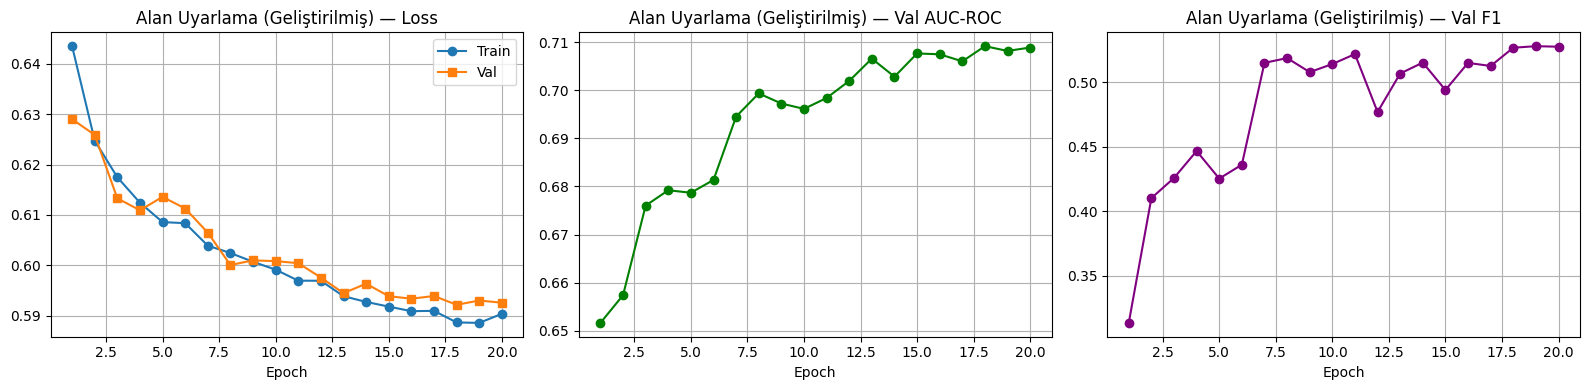


[Alan Uyarlama] TEST SONUÇLARI
  Loss : 0.5950
  AUC  : 0.7065
  F1   : 0.5297


(np.float64(0.7064505834187181), 0.5296630591063982)

In [ ]:
# Veriyi yükle
df = load_labels(LABEL_CSV, CLASSES)
train_loader, val_loader, test_loader = get_dataloaders(df, IMAGE_DIR, CLASSES)

# Sadece Alan Uyarlama modeli
print("\n>>> Geliştirilmiş Alan Uyarlama eğitimi başlıyor...\n")
adapt_model = DomainAdaptationModel(NUM_CLASSES)
hist_adapt  = train_model(adapt_model, train_loader, val_loader, "adapt")

# Grafik
plot_history(hist_adapt, "Alan Uyarlama (Geliştirilmiş)")

# Test
adapt_model2 = DomainAdaptationModel(NUM_CLASSES)
test_model(adapt_model2, test_loader, "best_adapt.pth", "Alan Uyarlama")

Güncellenmiş kodlar;

In [1]:
#Hücre 1
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
#Hücre 2
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Cihaz
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

# Sabitler
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
LR          = 3e-4
SEED        = 42
CLASSES     = ["Infiltration", "Effusion", "Atelectasis"]
NUM_CLASSES = len(CLASSES)

torch.manual_seed(SEED)
np.random.seed(SEED)

# Veri yolu
DATA_DIR  = "/content/drive/MyDrive/Derin_Ogrenme_Proje/temiz_veriler"
IMAGE_DIR = DATA_DIR
LABEL_CSV = os.path.join(DATA_DIR, "filtreli_etiketler.csv")
print(LABEL_CSV)

# CSV'yi yerel diske kopyala (Drive I/O hatalarını önlemek için)
import shutil
LOCAL_CSV = "/content/filtreli_etiketler.csv"
if not os.path.exists(LOCAL_CSV):
    shutil.copy(LABEL_CSV, LOCAL_CSV)
LABEL_CSV = LOCAL_CSV
print(f"CSV yerel diskte: {LABEL_CSV}")

Kullanılan cihaz: cuda
/content/drive/MyDrive/Derin_Ogrenme_Proje/temiz_veriler/filtreli_etiketler.csv
CSV yerel diskte: /content/filtreli_etiketler.csv


In [3]:
#Hücre 3
def load_labels(csv_path, classes):
    df = pd.read_csv(csv_path)
    df = df[["Image Index", "Finding Labels"]].copy()

    for cls in classes:
        df[cls] = df["Finding Labels"].apply(lambda x: 1 if cls in x else 0)

    mask        = df[classes].sum(axis=1) > 0
    normal_mask = df["Finding Labels"] == "No Finding"
    df_pos  = df[mask]
    df_neg  = df[normal_mask].sample(
        n=min(len(df_pos), df[normal_mask].shape[0]), random_state=SEED
    )
    df_final = pd.concat([df_pos, df_neg]).reset_index(drop=True)

    print(f"Toplam örnek: {len(df_final)}")
    for cls in classes:
        print(f"  {cls}: {df_final[cls].sum()} pozitif")
    return df_final


class ChestXrayDataset(Dataset):
    def __init__(self, df, image_dir, classes, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.classes   = classes
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["Image Index"])
        image    = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row[self.classes].values.astype(float), dtype=torch.float32
        )
        return image, label


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


def get_dataloaders(df, image_dir, classes):
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED)
    val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=SEED)

    train_ds = ChestXrayDataset(train_df, image_dir, classes, train_transform)
    val_ds   = ChestXrayDataset(val_df,   image_dir, classes, val_transform)
    test_ds  = ChestXrayDataset(test_df,  image_dir, classes, val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    # train_df'i pos_weight için döndürüyoruz
    return train_loader, val_loader, test_loader, train_df

In [4]:
#Hücre 4
class AdaptationBlock(nn.Module):
    """
    Çok dallı (multi-scale) CNN bloğu + SE attention
    Farklı kernel boyutlarıyla göğüs röntgeni dokusunu yakalar
    """
    def __init__(self):
        super().__init__()

        # Multi-scale dallar
        self.branch1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )

        # Birleştirme (48 → 32 → 3)
        self.merge = nn.Sequential(
            nn.Conv2d(48, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 3, kernel_size=1),
            nn.BatchNorm2d(3),
        )

        # Channel Attention (SE Block)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(3, 6),
            nn.ReLU(inplace=True),
            nn.Linear(6, 3),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        merged = torch.cat([b1, b2, b3], dim=1)
        out  = self.merge(merged)
        se_w = self.se(out).unsqueeze(-1).unsqueeze(-1)
        out  = out * se_w
        return self.relu(out)


class DomainAdaptationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.adapt = AdaptationBlock()

        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

        # Omurgayı tamamen dondur
        for param in backbone.parameters():
            param.requires_grad = False

        in_features = backbone.classifier.in_features  # 1024
        backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
        for param in backbone.classifier.parameters():
            param.requires_grad = True

        self.backbone = backbone

    def forward(self, x):
        x = self.adapt(x)
        return self.backbone(x)

In [5]:
#Hücre 5
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            all_probs.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)
    preds      = (all_probs >= 0.5).astype(int)

    auc_scores = [
        roc_auc_score(all_labels[:, i], all_probs[:, i])
        for i in range(all_labels.shape[1])
        if all_labels[:, i].sum() > 0
    ]
    mean_auc = np.mean(auc_scores)
    mean_f1  = f1_score(all_labels, preds, average="macro", zero_division=0)

    return total_loss / len(loader), mean_auc, mean_f1


def train_model(model, train_loader, val_loader, train_df, model_name="model"):
    model.to(device)

    # Sınıf dengesizliği için pos_weight (DataFrame'den hızlı hesap)
    pos_counts = train_df[CLASSES].sum(axis=0).values
    neg_counts = len(train_df) - pos_counts
    pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float32).to(device)
    print(f"Pos weights: {pos_weight}")

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler    = GradScaler()

    history  = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
    best_auc = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_auc, val_f1 = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        history["val_f1"].append(val_f1)

        print(f"[{model_name}] Epoch {epoch:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"AUC: {val_auc:.4f} | F1: {val_f1:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), f"best_{model_name}.pth")

    print(f"\n[{model_name}] En iyi Val AUC: {best_auc:.4f}")
    return history


def find_optimal_thresholds(model, val_loader):
    """Validation setinde her sınıf için en yüksek F1'i veren eşiği bul"""
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            all_probs.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.numpy())
    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)

    best_thresholds = []
    for i in range(all_labels.shape[1]):
        best_f1, best_t = 0, 0.5
        for t in np.arange(0.1, 0.9, 0.02):
            preds = (all_probs[:, i] >= t).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(best_t)
        print(f"  Sınıf {i} ({CLASSES[i]}): eşik={best_t:.2f}, F1={best_f1:.4f}")
    return np.array(best_thresholds)


def test_model_with_thresholds(model, test_loader, model_path, model_name, thresholds):
    """Optimal eşiklerle test et"""
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            all_probs.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.numpy())
    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)

    preds = (all_probs >= thresholds).astype(int)

    auc_scores = [
        roc_auc_score(all_labels[:, i], all_probs[:, i])
        for i in range(all_labels.shape[1])
        if all_labels[:, i].sum() > 0
    ]
    mean_auc = np.mean(auc_scores)
    mean_f1  = f1_score(all_labels, preds, average="macro", zero_division=0)

    print(f"\n{'='*50}")
    print(f"[{model_name}] TEST SONUÇLARI (Optimal Eşikler)")
    print(f"  AUC : {mean_auc:.4f}")
    print(f"  F1  : {mean_f1:.4f}")
    print(f"  Eşikler: {thresholds}")
    print(f"{'='*50}")

    print("\nSınıf bazlı sonuçlar:")
    for i, cls in enumerate(CLASSES):
        auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
        f1  = f1_score(all_labels[:, i], preds[:, i], zero_division=0)
        print(f"  {cls}: AUC={auc:.4f}, F1={f1:.4f}")

    return mean_auc, mean_f1


def plot_history(hist, title="Alan Uyarlama"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    epochs = range(1, NUM_EPOCHS + 1)

    axes[0].plot(epochs, hist["train_loss"], label="Train", marker="o")
    axes[0].plot(epochs, hist["val_loss"], label="Val", marker="s")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, hist["val_auc"], marker="o", color="green")
    axes[1].set_title(f"{title} — Val AUC-ROC")
    axes[1].set_xlabel("Epoch"); axes[1].grid(True)

    axes[2].plot(epochs, hist["val_f1"], marker="o", color="purple")
    axes[2].set_title(f"{title} — Val F1")
    axes[2].set_xlabel("Epoch"); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

Toplam örnek: 35430
  Infiltration: 19870 pozitif
  Effusion: 13307 pozitif
  Atelectasis: 11535 pozitif

>>> Geliştirilmiş Alan Uyarlama eğitimi başlıyor...

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 234MB/s]


Pos weights: tensor([0.7801, 1.6684, 2.0699], device='cuda:0')
[adapt] Epoch 01/20 | Train Loss: 0.7811 | Val Loss: 0.7643 | AUC: 0.6531 | F1: 0.5450
[adapt] Epoch 02/20 | Train Loss: 0.7593 | Val Loss: 0.7621 | AUC: 0.6625 | F1: 0.5649
[adapt] Epoch 03/20 | Train Loss: 0.7513 | Val Loss: 0.7429 | AUC: 0.6806 | F1: 0.5874
[adapt] Epoch 04/20 | Train Loss: 0.7477 | Val Loss: 0.7470 | AUC: 0.6732 | F1: 0.5818
[adapt] Epoch 05/20 | Train Loss: 0.7432 | Val Loss: 0.7408 | AUC: 0.6869 | F1: 0.5808
[adapt] Epoch 06/20 | Train Loss: 0.7402 | Val Loss: 0.7427 | AUC: 0.6844 | F1: 0.5819
[adapt] Epoch 07/20 | Train Loss: 0.7378 | Val Loss: 0.7348 | AUC: 0.6890 | F1: 0.5801
[adapt] Epoch 08/20 | Train Loss: 0.7337 | Val Loss: 0.7364 | AUC: 0.6880 | F1: 0.5820
[adapt] Epoch 09/20 | Train Loss: 0.7307 | Val Loss: 0.7356 | AUC: 0.6886 | F1: 0.5920
[adapt] Epoch 10/20 | Train Loss: 0.7288 | Val Loss: 0.7316 | AUC: 0.6967 | F1: 0.5910
[adapt] Epoch 11/20 | Train Loss: 0.7272 | Val Loss: 0.7356 | AUC: 

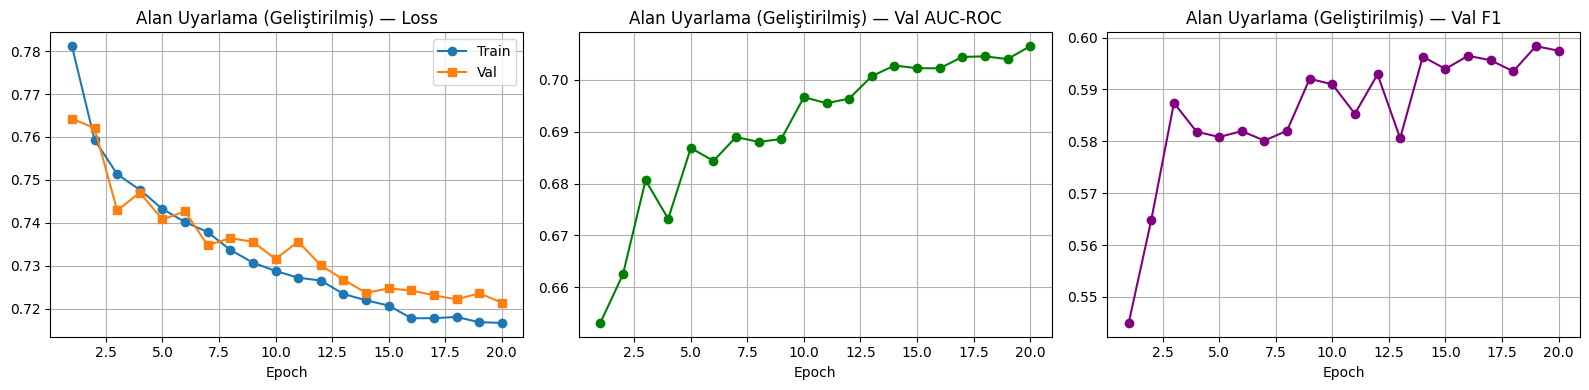


>>> Optimal eşikler aranıyor...
  Sınıf 0 (Infiltration): eşik=0.32, F1=0.7272
  Sınıf 1 (Effusion): eşik=0.40, F1=0.6218
  Sınıf 2 (Atelectasis): eşik=0.46, F1=0.5437


In [ ]:
#Hücre 6
# Veriyi yükle
df = load_labels(LABEL_CSV, CLASSES)
train_loader, val_loader, test_loader, train_df = get_dataloaders(df, IMAGE_DIR, CLASSES)

# Eğitim
print("\n>>> Geliştirilmiş Alan Uyarlama eğitimi başlıyor...\n")
adapt_model = DomainAdaptationModel(NUM_CLASSES)
hist_adapt  = train_model(adapt_model, train_loader, val_loader, train_df, "adapt")

# Grafik
plot_history(hist_adapt, "Alan Uyarlama (Geliştirilmiş)")

# Optimal eşikleri val setinden bul
print("\n>>> Optimal eşikler aranıyor...")
adapt_model.load_state_dict(torch.load("best_adapt.pth", map_location=device))
optimal_thresholds = find_optimal_thresholds(adapt_model, val_loader)

# Test (optimal eşiklerle)
adapt_model2 = DomainAdaptationModel(NUM_CLASSES)
test_model_with_thresholds(adapt_model2, test_loader, "best_adapt.pth",
                            "Alan Uyarlama", optimal_thresholds)